# Convolution Neural Network avec Keras

In [1]:
import os
import cv2
# si nécessaire : conda install -c conda-forge opencv
# ou sinon : https://pypi.org/project/opencv-python/
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

On importe les librairies nécessaires de Keras

In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import SGD, RMSprop, Adam, Adadelta
from tensorflow.keras.utils import to_categorical

## Importation et préparation des données

Télécharger les données depuis :

https://box.ec-nantes.fr:443/index.php/s/2NxopNZS3FTRBcr

Adresse du dossier où sont entreposées les données:

In [3]:
data_path="/content/data_animals (2).zip"

In [4]:
!unzip "{data_path}"

Archive:  /content/data_animals (2).zip
   creating: data_animals/
   creating: data_animals/dogs/
  inflating: data_animals/dogs/dog.167.jpg  
  inflating: data_animals/dogs/dog.173.jpg  
  inflating: data_animals/dogs/dog.36.jpg  
  inflating: data_animals/dogs/dog.22.jpg  
  inflating: data_animals/dogs/dog.198.jpg  
  inflating: data_animals/dogs/dog.199.jpg  
  inflating: data_animals/dogs/dog.23.jpg  
  inflating: data_animals/dogs/dog.37.jpg  
  inflating: data_animals/dogs/dog.172.jpg  
  inflating: data_animals/dogs/dog.166.jpg  
  inflating: data_animals/dogs/dog.170.jpg  
  inflating: data_animals/dogs/dog.164.jpg  
  inflating: data_animals/dogs/dog.21.jpg  
  inflating: data_animals/dogs/dog.158.jpg  
  inflating: data_animals/dogs/dog.35.jpg  
  inflating: data_animals/dogs/dog.159.jpg  
  inflating: data_animals/dogs/dog.34.jpg  
  inflating: data_animals/dogs/dog.20.jpg  
  inflating: data_animals/dogs/dog.165.jpg  
  inflating: data_animals/dogs/dog.171.jpg  
  inflati

In [11]:
data_path = "/content/data_animals"

La fonction `os.listdir()` permet de lister le contenu du dossier `data_animals` (un repertoire par classe).

In [12]:
data_dir_list = os.listdir(data_path)
print(data_dir_list)
num_classes = len(data_dir_list)
print(num_classes)

['Humans', 'horses', 'dogs', 'cats']
4


Toutes les images ne sont pas au même format (nb de pixels).
Le réseau CNN impose que toutes les données aient la même dimension. Il nous faudra  transformer les images pour qu'elles soient toutes au même format : 128x 128.

In [7]:
img_rows=128
img_cols=128

Lorsque les images en entrée du réseau sont en couleur, on utilise 3 canaux(RGB).

Ici, pour simplifier, nous allons préalablement transformer les images en niveaux de gris et de ce fait nous n'utiliserons qu'un seul canal en entrée du réseau.

In [8]:
num_channel=1

> Compléter le script ci-dessous pour importer les images en niveaux de gris et sous la forme de tableaux 128x128, dans la liste img_data_list.
*  `my_img = cv2.imread("file")`  : lecture d'un fichier image
*  `cv2.cvtColor(my_img, cv2.COLOR_BGR2GRAY)` : convertit le fichier image en niveaux de gris
*  `cv2.resize(input_img,(n,p))` : redimensionne l'image au format n x p

In [13]:
from sklearn import preprocessing

img_data_list=[]

for dataset in data_dir_list: # boucle sur les 4 repertoires
    img_list=os.listdir(data_path+'/'+ dataset)  #

    print ('Loaded the images of dataset-'+'{}\n'.format(dataset))
    for img in img_list:
        if img.startswith('._'): # Skip hidden files from macOS
            continue
        input_img_raw=  cv2.imread(data_path+'/'+ dataset+'/'+img)
        input_img_grey= cv2.cvtColor(input_img_raw, cv2.COLOR_BGR2GRAY)
        input_img_flatten=cv2.resize(input_img_grey,(128,128)).flatten()
        img_data_list.append(input_img_flatten)


img_data = np.array(img_data_list)
img_data = img_data.astype('float32')

img_data_scaled = preprocessing.scale(img_data)
print (img_data_scaled.shape)

print (np.mean(img_data_scaled))
print (np.std(img_data_scaled))

print (img_data_scaled.mean(axis=0))
print (img_data_scaled.std(axis=0))

Loaded the images of dataset-Humans

Loaded the images of dataset-horses

Loaded the images of dataset-dogs

Loaded the images of dataset-cats

(808, 16384)
2.9267504e-08
1.0000001
[-8.7193925e-08 -4.4113339e-08  3.0244930e-08 ... -2.6851598e-08
  8.2177692e-08  4.9277109e-08]
[0.9999995 1.0000001 1.0000005 ... 0.9999996 1.0000001 0.9999998]


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_data.py:258: UserWarning: Numerical issues were encountered when centering the data and might not be solved. Dataset may contain too large values. You may need to prescale your features.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_data.py:277: UserWarning: Numerical issues were encountered when scaling the data and might not be solved. The standard deviation of the data is probably very close to 0. 
  warnings.warn(


> Quelle la dimension du tableau `img_data` ?

In [14]:
print('La dimension du tableau img_data est', img_data.shape)

La dimension du tableau img_data est (808, 16384)


De façon générale, la première couche du réseau de convolution  prend en entrée un objet de dimension 3 : hauteur, largeur, profondeur,  où la profondeur correspond aux nombres de canaux.

Avec Tensor Flow (ici en backend) la profondeur doit être donnée en dernière position.

Cette dimension est ici "factice"  car nos images sont en niveaux gris, elle est néanmoins nécessaire car attendue par les fonctions de Keras et Tensor Flow.

L'échantillon d'images doit finalement se présenter sous la forme d'un objet de dimension 4: (nombre d'échantillons, hauteur, largeur, profondeur)

Nous redimensionnons les données pour qu'elle se présente ainsi :

In [15]:
img_data_reshape=img_data_scaled.reshape(img_data.shape[0],
                                        img_rows,img_cols,
                                        num_channel)
print (img_data_reshape.shape)



(808, 128, 128, 1)


La dimension d'une image en entrée du réseau est la suivante :

In [16]:
input_shape=img_data_reshape[0].shape # (128, 128, 1)
input_shape

(128, 128, 1)

Nous indiquons maintenant les labels des images:

In [17]:
num_of_samples = img_data_reshape.shape[0]
labels = np.ones((num_of_samples,),dtype='int64')
labels[0:202]=0
labels[202:404]=1
labels[404:606]=2
labels[606:]=3

names = ['cats','dogs','horses','humans']

> Convertir les labels en "one-hot encoding"

In [18]:
Labels = to_categorical(labels)

In [19]:
print(labels)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 

> Séparer  aléatoirement les données en un échantillon d'apprentissage (80%) et un échantillon de test (20%). Assurez-vous que les données d'apprentissage prennent bien la forme d'un tableau de dimension 4.

In [20]:
X_train, X_test, Y_train, Y_test = train_test_split(img_data_reshape, Labels, test_size=0.2)
X_train.shape

(646, 128, 128, 1)

## Définition de l'architecture du modèle

Nous définissons ci-dessous les deux premiers niveaux de convolution du réseau CNN.
Chacune de ces deux couches est définie comme suit :
+ 32 noyaux (filtres)
+ Pas (stride) = 1
+ Kernel size = (3,3)
+ padding = 'same' (i.e. 0 padding : bordures à 0)
+ activation : relu

> Créer un modèle séquentiel que vous nommerez `my_first_CNN` composé de 4 couches succesives (conv + relu + conv + relu).    
> Voir  [ici](https://keras.io/layers/convolutional/#conv2d) et  [ici](https://keras.io/examples/vision/mnist_convnet/) pour la synthaxe de la couche de convolution `Conv2D`.

In [21]:
from tensorflow import keras

my_first_CNN = Sequential(
    [keras.Input(shape = input_shape),
    Conv2D(32, kernel_size = (3,3), strides = 1, padding = 'same', activation = 'relu'),
     MaxPooling2D(pool_size=(2, 2)),
    Conv2D(32, kernel_size = (3,3), strides = 1, padding = 'same', activation = 'relu'),
     MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dropout(0.5),
    Dense(num_classes, activation="softmax"),
    ]
)



In [ ]:
my_first_CNN.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 32768)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32768)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 4)                   │         131,076 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 140,644 (549.39 KB)

 Trainable params: 140,644 (549.39 KB)

 Non-trainable params: 0 (0.00 B)

> Executez les codes ci-dessous et decrire les sorties obtenues

In [22]:
print(my_first_CNN.input_shape)
#print(my_first_CNN.layers[0].input_shape)
#print(my_first_CNN.layers[1].input_shape)

(None, 128, 128, 1)


(`batch_size`,`n_l`,`n_c`,`nb de canaux`)

Keras dimensionnera ensuite correctement les couches en fonction du `batch_size` choisi par l'utilisateur.

> Passer `batch_size=16` en argument de `Conv2D` et vérifier que cela a bien été pris en compte dans les dimensions de la couche cachée de `my_first_CNN`.

In [23]:
my_first_CNN = Sequential(
    [
        Conv2D(32, kernel_size=(3, 3), strides=1, padding='same', activation='relu', input_shape=input_shape),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(32, kernel_size=(3, 3), strides=1, padding='same', activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Flatten(),
        Dropout(0.5),
        Dense(num_classes, activation="softmax"),
    ]
)

batch_size = 16
dummy_input = np.random.random((batch_size, *input_shape))
output = my_first_CNN(dummy_input)

# Dimensions des couches
print("Dimensions d'entrée (après batch_size):", dummy_input.shape)
print("Dimensions de sortie (après batch_size):", output.shape)




/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Dimensions d'entrée (après batch_size): (16, 128, 128, 1)
Dimensions de sortie (après batch_size): (16, 4)


In [ ]:
print(my_first_CNN.input_shape)
#print(my_first_CNN.layers[0].input_shape)
#print(my_first_CNN.layers[1].input_shape)



(None, 128, 128, 1)


> Executez les codes ci-dessous et decrire les sorties obtenues. Expliquer en particulier la dimension de la troisième couche en utilisant `get_weights`.

In [ ]:
my_first_CNN.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 128, 128, 32)      320       
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 64, 64, 32)       0         
 2D)                                                             
                                                                 
 conv2d_3 (Conv2D)           (None, 64, 64, 32)        9248      
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 32, 32, 32)       0         
 2D)                                                             
                                                                 
 flatten_1 (Flatten)         (None, 32768)             0         
                                                                 
 dropout_1 (Dropout)         (None, 32768)            

In [ ]:
np.shape(my_first_CNN.layers[2].get_weights()[0])

(3, 3, 32, 32)

Multichannel convolution:
\begin{eqnarray} Z(i,j,l) &= & ( V \star K ) (i,j,l) \\
& =  & \sum_{u,v,w}   V (i+u, j+v,w ) w_{u,v,l,w}
\end{eqnarray}
where
+ $V$  and $Z$ have the same dimensions (multichannel).
+ $K(u,v,l,w) $ gives the connection strength between a unit in channel $l$ of the output and a unit in channel $w$ of the input, with an offset of  $u$ rows and $v$ columns between the output unit and the input unit.

Le nombre de poids à estimer vaut donc :

**9216**

Le nombre de paramètres à estimer pour les termes de biais :

**32**

On a bien que pour la troisième couche 9248 = **9216 +32**

> Vérifier que les poids sont (déjà) initialisés aléatoirement alors que les biais sont initialisés à 0.

In [ ]:
my_first_CNN.layers[0].get_weights()

[array([[[[ 0.06955788, -0.0199675 , -0.13894217, -0.1142664 ,
           -0.02083059,  0.03123203, -0.05041535,  0.09425013,
           -0.00259438,  0.1117814 ,  0.11706536,  0.0525631 ,
           -0.02770179, -0.07014802,  0.04448527, -0.01480907,
           -0.02126157, -0.11332215, -0.00162423, -0.14186041,
            0.06543975, -0.00662792, -0.06807832,  0.09409776,
           -0.13406213, -0.03272159,  0.06509261, -0.11344984,
            0.08093178,  0.0850271 ,  0.02956027, -0.06730663]],
 
         [[ 0.03546064, -0.08453699, -0.14144793, -0.11479947,
           -0.11801653, -0.03239383, -0.08765456, -0.10581861,
           -0.02299903, -0.0308956 , -0.05088513,  0.09991316,
           -0.0650866 ,  0.04481879, -0.00055538,  0.02762923,
            0.13804714, -0.03774169,  0.05976786,  0.00474121,
           -0.11282689, -0.03447054, -0.13962063, -0.01987262,
           -0.00638017,  0.10773841,  0.11354421,  0.11441682,
            0.13599418, -0.05870508,  0.03710254, -

> Construire maintenant l'architecture complète du réseau `my_first_CNN` :
+ Convolution à 32 filtres de taille (3,3), zero padding
+ Activation Relu
+ Convolution à 32 filtres de taille (3,3), zero padding
+ Activation Relu
+ Maxpooling2D (2,2) [documentation](https://keras.io/api/layers/pooling_layers/max_pooling2d/)
+ Dropout(0.5) [documentation](https://keras.io/api/layers/regularization_layers/dropout/)
+ Convolution à 64 filtres de taille (3,3), zero padding
+ Maxpooling2D (2,2)
+ Dropout(0.5)
+ Flatten  [documentation](https://keras.io/api/layers/reshaping_layers/flatten/)
+ Dense(64)
+ Activation Relu
+ Dropout(0.5)
+ Dense(4)
+ Softmax   
>
> Afficher un résumé de l'architecture avec `my_first_CNN.summary`

In [25]:
my_first_CNN = Sequential(
    [
        keras.Input(shape=input_shape),
        Conv2D(32, kernel_size=(3, 3), strides=1, padding='same', activation='relu'),
        Conv2D(32, kernel_size=(3, 3), strides=1, padding='same', activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.5),
        Conv2D(64, kernel_size=(3, 3), strides=1, padding='same', activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.5),
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation="softmax"),
    ]
)


In [26]:
my_first_CNN.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │     4,194,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,222,692 (16.11 MB)

 Trainable params: 4,222,692 (16.11 MB)

 Non-trainable params: 0 (0.00 B)

## Apprentissage du CNN

> Ajuster le modèle
- avec la méthode sgd (avec un taux d'apprentissage de 0.01 et momentum de 0.9)
- puis la méthode adam.

In [27]:
sgd = SGD(learning_rate=0.01, momentum=0.9)

batch_size = 16
epochs = 15

my_first_CNN.compile(loss="categorical_crossentropy", optimizer=sgd, metrics=["accuracy"])

history_sgd = my_first_CNN.fit(X_train, Y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1, verbose=0)

> Tracer en fonction du nombre d'epochs le risque de cross-entropy ainsi que la précision pour les échantillons d'apprentissage et de validation.

In [28]:
my_first_CNN.compile(loss="categorical_crossentropy", optimizer='adam', metrics=["accuracy"])

history_adam = my_first_CNN.fit(X_train, Y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1, verbose=0)

In [31]:
print(history_sgd.history['val_loss'])

[1.3871675729751587, 1.3444690704345703, 1.296639084815979, 1.2758928537368774, 1.182708740234375, 1.1925749778747559, 1.194644570350647, 1.1073940992355347, 1.1007784605026245, 1.2382148504257202, 1.1456561088562012, 1.1866827011108398, 1.1378902196884155, 1.218016266822815, 1.208345651626587]


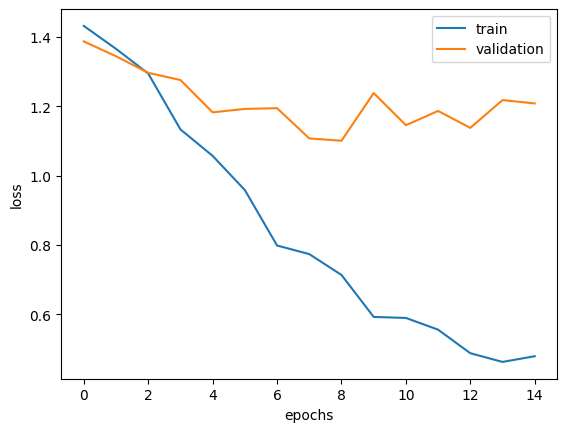

In [32]:
plt.plot(history_sgd.history['loss'],label ="train")
plt.plot(history_sgd.history['val_loss'],label ="validation")
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(loc='best')

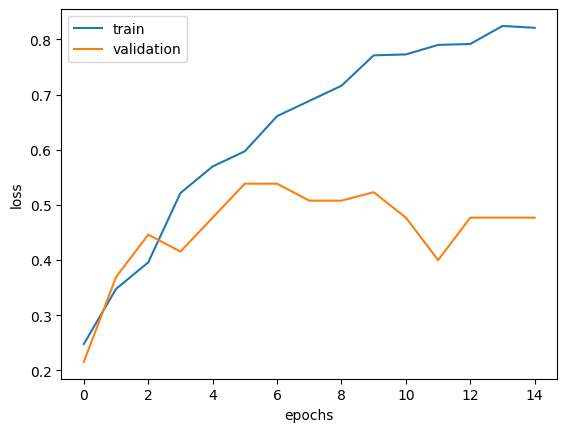

In [34]:
plt.plot(history_sgd.history['accuracy'],label ="train")
plt.plot(history_sgd.history['val_accuracy'],label ="validation")
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(loc='best')

> Donner le risque de cross-entropy ainsi que la précision pour l'échantillon de test.

In [35]:
my_first_CNN.compile(loss="categorical_crossentropy", optimizer=sgd, metrics=["accuracy"])

my_first_CNN.evaluate(X_test, Y_test)

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 308ms/step - accuracy: 0.5675 - loss: 1.3174


[1.3164849281311035, 0.5493826866149902]

## Matrice de confusion

> Utilisez les outils `classification_report()` et `confusion_matrix()` de `sklearn.metrics` pour décrire les performances du réseau de neurones.

In [36]:
def indice_du_max(L):
    res = 0
    M = L[0]
    n = len(L)
    for k in range(n):
        if L[k] > M:
            M = L[k]
            res = k
    return res

Y_pred = to_categorical([indice_du_max(i) for i in my_first_CNN.predict(X_test)])

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 315ms/step


In [37]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(Y_test,Y_pred))


cm = confusion_matrix(np.argmax(Y_test,axis=1),np.argmax(Y_pred,axis=1))

              precision    recall  f1-score   support

           0       0.80      0.70      0.75        47
           1       0.52      0.43      0.47        37
           2       0.40      0.54      0.46        39
           3       0.50      0.49      0.49        39

   micro avg       0.55      0.55      0.55       162
   macro avg       0.56      0.54      0.54       162
weighted avg       0.57      0.55      0.55       162
 samples avg       0.55      0.55      0.55       162



> Afficher la matrice de confusion à l'aide de la fonction `ConfusionMatrixDisplay`

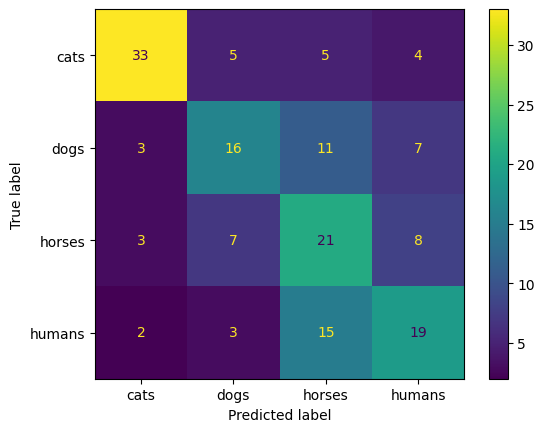

In [38]:
from sklearn.metrics import ConfusionMatrixDisplay

display = ConfusionMatrixDisplay(cm, display_labels=names)
display.plot()
plt.show()